In [2]:
import pandas as pd 

In [3]:
data = pd.read_csv("/home/patel-krish/Documents/1768456274717-ML Project - Random Forest Hotel Cancellation Prediction Analysis 16955485770.txt")

In [4]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,06/09/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,07/09/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,07/09/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,07/09/2017


In [5]:
for col in data.columns:
    print ("COLUMN:",col)
    print(data[col].unique())
    print("----------")

COLUMN: hotel
['Resort Hotel' 'City Hotel']
----------
COLUMN: is_canceled
[0 1]
----------
COLUMN: lead_time
[342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192
 361 207 174 3

In [6]:
data.fillna("Other")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,Other,Other,0,Transient,0.00,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,Other,Other,0,Transient,0.00,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,Other,Other,0,Transient,75.00,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,Other,0,Transient,75.00,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,Other,0,Transient,98.00,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,Other,0,Transient,96.14,0,0,Check-Out,06/09/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,Other,0,Transient,225.43,0,2,Check-Out,07/09/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,Other,0,Transient,157.71,0,4,Check-Out,07/09/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,Other,0,Transient,104.40,0,0,Check-Out,07/09/2017


In [7]:
data["agent"] = pd.to_numeric(data["agent"], errors="coerce")

data["agent"].fillna(data["agent"].mean(), inplace=True)

/tmp/ipykernel_5764/1687670355.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["agent"].fillna(data["agent"].mean(), inplace=True)


In [8]:
data.dropna(inplace=True)



In [9]:
data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,...,No Deposit,86.693382,110.0,0,Transient,107.42,0,0,Check-Out,02/07/2015
218,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,No Deposit,86.693382,110.0,0,Transient,104.72,0,1,Canceled,08/07/2015
219,Resort Hotel,1,1,2015,July,28,8,0,1,2,...,No Deposit,86.693382,110.0,0,Transient,104.72,0,1,Canceled,08/07/2015
220,Resort Hotel,0,1,2015,July,28,8,0,2,2,...,No Deposit,86.693382,110.0,0,Transient,104.72,1,1,Check-Out,10/07/2015
295,Resort Hotel,0,84,2015,July,28,11,1,1,2,...,No Deposit,86.693382,113.0,0,Transient,100.00,1,0,Check-Out,13/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119119,City Hotel,0,40,2017,August,35,29,0,1,1,...,No Deposit,86.693382,451.0,0,Transient,95.00,0,0,Check-Out,30/08/2017
119122,City Hotel,0,40,2017,August,35,29,0,1,1,...,No Deposit,86.693382,451.0,0,Transient,95.00,0,0,Check-Out,30/08/2017
119123,City Hotel,0,40,2017,August,35,29,0,1,1,...,No Deposit,86.693382,451.0,0,Transient,95.00,0,0,Check-Out,30/08/2017
119124,City Hotel,0,0,2017,August,35,29,0,1,1,...,No Deposit,86.693382,72.0,0,Transient,0.00,0,2,Check-Out,30/08/2017


In [10]:
import matplotlib.pyplot as plt

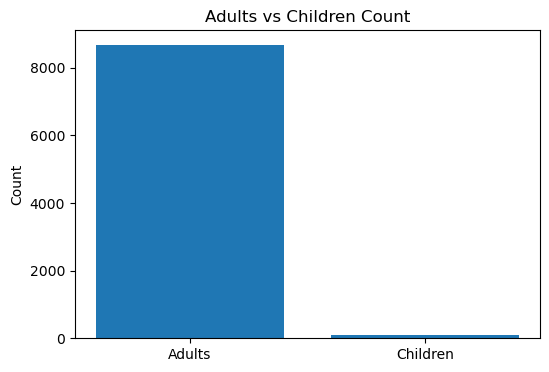

In [11]:
plt.figure(figsize=(6,4))

adult_count = data["adults"].sum()
children_count = data["children"].sum()

plt.bar(["Adults","Children"], [adult_count, children_count])

plt.title("Adults vs Children Count")
plt.ylabel("Count")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = le.fit_transform(data[col])


In [14]:
x = data.drop("is_canceled",axis=1) # 1. Create features and target data

In [15]:
y = data["is_canceled"]

In [16]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.5,random_state=32)

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
rf_model = RandomForestClassifier(n_estimators=3,random_state=32)

In [26]:
rf_model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=3, random_state=32)

In [63]:
from sklearn.metrics import precision_score, recall_score,accuracy_score,confusion_matrix,classification_report

In [71]:
def evaluate_model(model,x_test,y_test):
    y_pred= rf_model.predict(x_test)

    print("Precision Score:", precision_score(y_test, y_pred))
    print("Recall Score:", recall_score(y_test, y_pred))
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [75]:
cm = confusion_matrix(y_test,ypred)

In [73]:
ypred= rf_model.predict(x_test)

In [76]:
import seaborn as sns

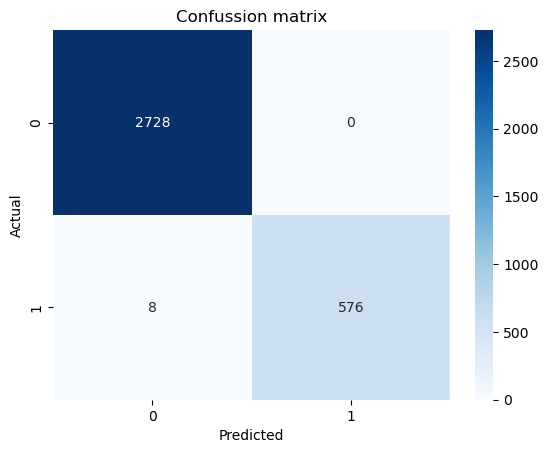

In [78]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confussion matrix")
plt.show()